In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(r"../data/benin.csv", encoding="latin1")  # Update with the correct path to your dataset

C:\Users\Fitsum\AppData\Local\Temp\ipykernel_14384\802354762.py:6: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"../data/benin.csv", encoding="latin1")  # Update with the correct path to your dataset


In [3]:
df.describe()
df.isna().sum()


Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525601
dtype: int64

In [4]:
# Remove non-numeric characters
df['GHI'] = df['GHI'].str.replace(r'[^\d.-]', '', regex=True)

In [6]:
print(df['GHI'].unique())

['' '-1.2' '-1.1' ... '183.4' '134.9' nan]


In [7]:
# Remove non-numeric characters
df['GHI'] = df['GHI'].str.replace(r'[^\d.-]', '', regex=True)

# Convert to numeric, coercing errors to NaN
df['GHI'] = pd.to_numeric(df['GHI'], errors='coerce')

In [8]:
df['GHI'].fillna(df['GHI'].median(), inplace=True)

C:\Users\Fitsum\AppData\Local\Temp\ipykernel_14384\304630717.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GHI'].fillna(df['GHI'].median(), inplace=True)


In [9]:
from scipy.stats import zscore

outlier_columns = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
df['zscore_GHI'] = zscore(df['GHI'].fillna(df['GHI'].median()))
outliers = df[df['zscore_GHI'].abs() > 3]


In [10]:
# Handle numeric columns
numeric_columns = df.select_dtypes(include=['number']).columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

# Handle non-numeric columns
non_numeric_columns = df.select_dtypes(exclude=['number']).columns
df[non_numeric_columns] = df[non_numeric_columns].fillna('Unknown')

# Verify no missing values remain
print(df.isna().sum())

Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525601
zscore_GHI            0
dtype: int64


In [12]:
df.fillna(df.select_dtypes(include='number').median(), inplace=True)


In [16]:
print(df['Timestamp'].unique())

[<NA> '2021-08-09 00:01' '2021-08-09 00:02' ... '2022-08-08 23:58'
 '2022-08-08 23:59' '2022-08-09 00:00']


In [15]:
df['Timestamp'] = df['Timestamp'].replace('yyyy-mm-dd hh:mm', pd.NA)

In [17]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

In [18]:
# Option 1: Drop rows with missing Timestamps
df.dropna(subset=['Timestamp'], inplace=True)

# Option 2: Fill missing Timestamps with a default value
# df['Timestamp'].fillna(pd.Timestamp('2022-01-01'), inplace=True)

<Axes: xlabel='Timestamp'>

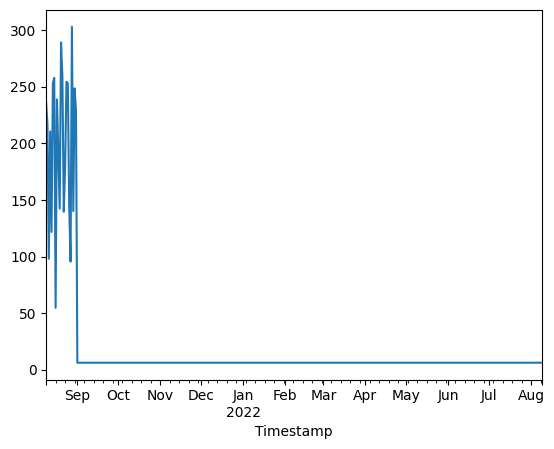

In [19]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp').resample('D')['GHI'].mean().plot()


In [21]:
print(df.dtypes)
print(df[['ModA', 'ModB']].head())
df['ModA'] = pd.to_numeric(df['ModA'], errors='coerce')
df['ModB'] = pd.to_numeric(df['ModB'], errors='coerce')
df[['ModA', 'ModB']] = df[['ModA', 'ModB']].fillna(0)  # Replace 0 with your desired value

Timestamp        datetime64[ns]
GHI                     float64
DNI                      object
DHI                      object
ModA                     object
ModB                     object
Tamb                     object
RH                       object
WS                       object
WSgust                   object
WSstdev                  object
WD                       object
WDstdev                  object
BP                       object
Cleaning                 object
Precipitation            object
TModA                    object
TModB                    object
Comments                float64
zscore_GHI              float64
dtype: object
  ModA ModB
1    0    0
2    0    0
3    0    0
4    0    0
5    0    0


<Axes: xlabel='Cleaning'>

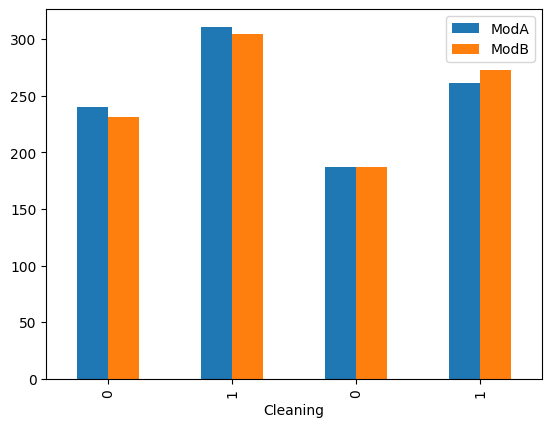

In [22]:
df.groupby('Cleaning')[['ModA', 'ModB']].mean().plot(kind='bar')


<Axes: >

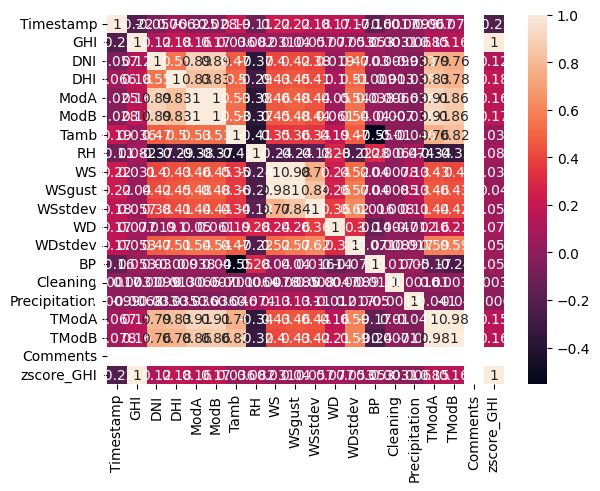

In [23]:
sns.heatmap(df.corr(), annot=True)


In [25]:
import os

os.makedirs('data', exist_ok=True)
df.to_csv('data/benin_clean.csv', index=False)